# Speed Dating - niezrównoważone klasy


### Importy i wczytanie danych


In [90]:
import numpy as np
import pandas as pd
from sklearn.datasets import fetch_openml
import matplotlib.pyplot as plt
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, recall_score, precision_score, f1_score, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve
from imblearn.metrics import classification_report_imbalanced
from sklearn.manifold import TSNE
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from imblearn.pipeline import Pipeline as ImbPipe
from sklearn.ensemble import RandomForestClassifier
from imblearn.ensemble import BalancedRandomForestClassifier, EasyEnsembleClassifier

ds = fetch_openml(data_id=40536, as_frame=True)
df = ds.frame.copy()
df['match'] = df['match'].astype(int)

print(df.shape)
print(df.dtypes.value_counts())
                                                              
df.head()

(8378, 121)
float64     57
category    35
category    12
int64        3
category     2
category     2
category     2
category     2
category     1
category     1
category     1
category     1
category     1
category     1
Name: count, dtype: int64


,has_null,wave,gender,age,age_o,d_age,d_d_age,race,race_o,samerace,...,expected_num_matches,d_expected_happy_with_sd_people,d_expected_num_interested_in_me,d_expected_num_matches,like,guess_prob_liked,d_like,d_guess_prob_liked,met,match
0,0,1,female,21.0,27.0,6,[4-6],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,0
1,0,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,5.0,[6-8],[5-6],1.0,0
2,1,1,female,21.0,22.0,1,[0-1],Asian/Pacific Islander/Asian-American,Asian/Pacific Islander/Asian-American,1,...,4.0,[0-4],[0-3],[3-5],7.0,NaN,[6-8],[0-4],1.0,1
3,0,1,female,21.0,23.0,2,[2-3],Asian/Pacific Islander/Asian-American,European/Caucasian-American,0,...,4.0,[0-4],[0-3],[3-5],7.0,6.0,[6-8],[5-6],0.0,1
4,0,1,female,21.0,24.0,3,[2-3],Asian/Pacific Islander/Asian-American,Latino/Hispanic American,0,...,4.0,[0-4],[0-3],[3-5],6.0,6.0,[6-8],[5-6],0.0,1


In [91]:
df.info()

df.describe().T

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8378 entries, 0 to 8377
Columns: 121 entries, has_null to match
dtypes: category(61), float64(57), int64(3)
memory usage: 4.3 MB


,count,mean,std,min,25%,50%,75%,max
wave,8378.0,11.350919,5.995903,1.00,7.00,11.00,15.00,21.00
age,8283.0,26.358928,3.566763,18.00,24.00,26.00,28.00,55.00
age_o,8274.0,26.364999,3.563648,18.00,24.00,26.00,28.00,55.00
d_age,8378.0,4.185605,4.596171,0.00,1.00,3.00,5.00,37.00
importance_same_race,8299.0,3.784793,2.845708,0.00,1.00,3.00,6.00,10.00
importance_same_religion,8299.0,3.651645,2.805237,1.00,1.00,3.00,6.00,10.00
pref_o_attractive,8289.0,22.495347,12.569802,0.00,15.00,20.00,25.00,100.00
pref_o_sincere,8289.0,17.396867,7.044003,0.00,15.00,18.37,20.00,60.00
pref_o_intelligence,8289.0,20.270759,6.782895,0.00,17.39,20.00,23.81,50.00
pref_o_funny,8280.0,17.459714,6.085526,0.00,15.00,18.00,20.00,50.00


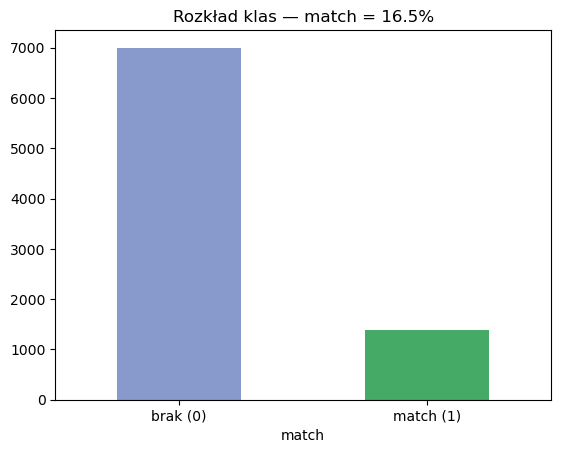

In [ ]:
ax = df['match'].value_counts().plot.bar(color=['#8899cc','#44aa66'])
ax.set_xticklabels(['brak (0)','match (1)'], rotation=0)
ax.set_title(f"Rozkład klas - match = {df['match'].mean():.1%}")
plt.show()

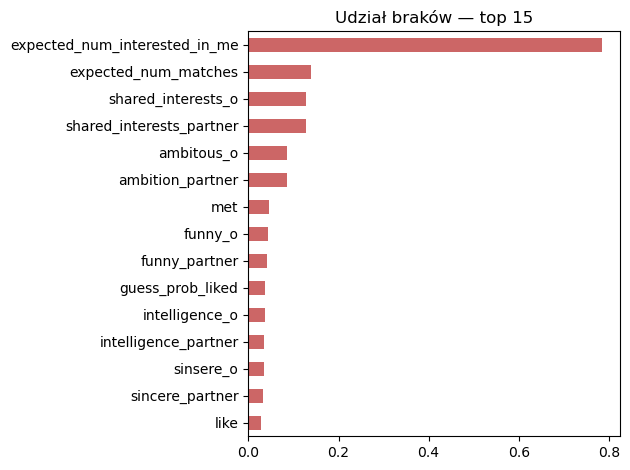

In [ ]:
miss = df.isna().mean().sort_values(ascending=False)
miss[miss > 0].head(15).plot.barh(color='#cc6666').invert_yaxis()
plt.title('Udział braków - top 15'); plt.tight_layout(); plt.show()

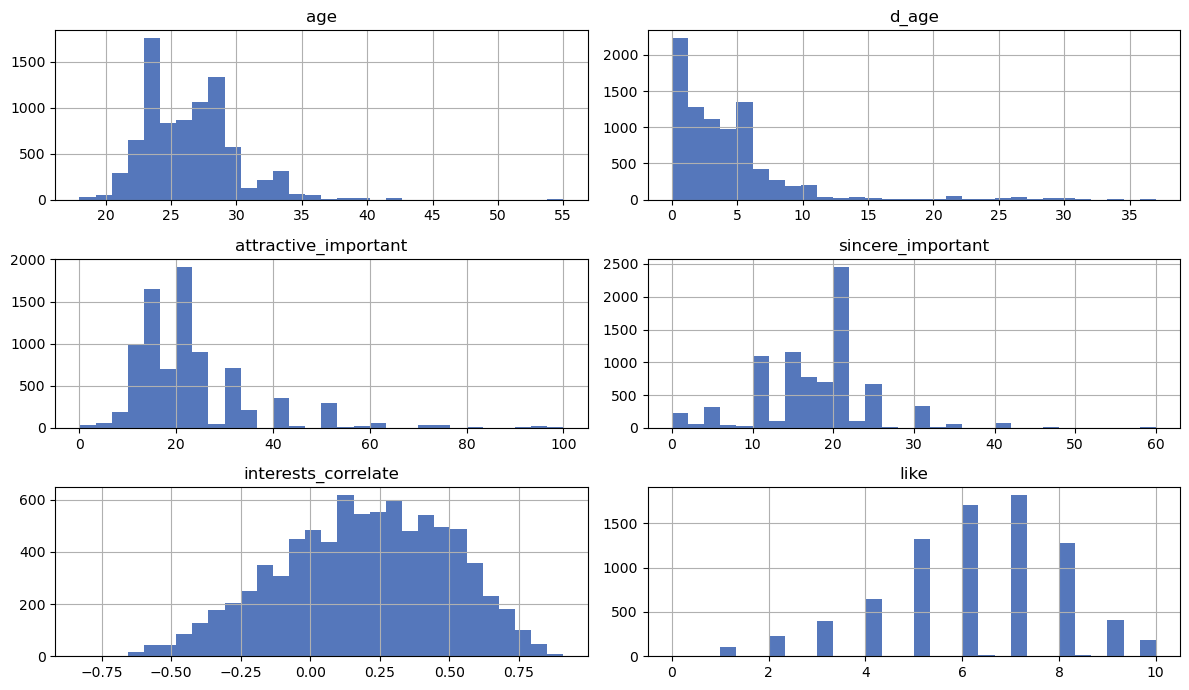

In [94]:
cols = ['age','d_age','attractive_important','sincere_important',
        'interests_correlate','like']
df[cols].hist(figsize=(12,7), bins=30, color='#5577bb')
plt.tight_layout(); plt.show()

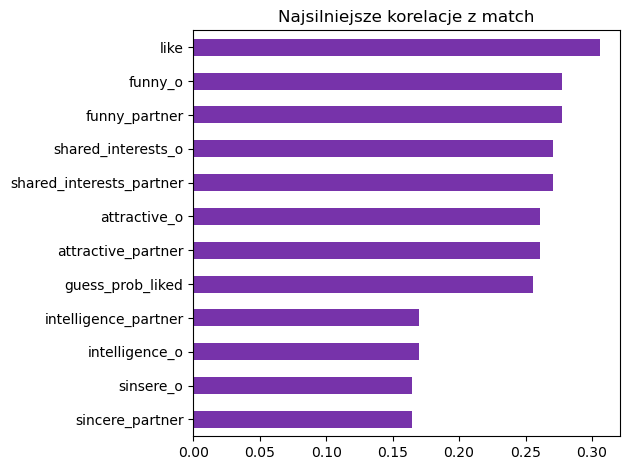

In [95]:
num = df.select_dtypes('number')
corr = num.corr()['match'].drop('match').sort_values(key=abs, ascending=False).head(12)
corr.plot.barh(color='#7733aa').invert_yaxis()
plt.title('Najsilniejsze korelacje z match'); plt.tight_layout(); plt.show()

### Zadanie 1.2 - usunięcie wycieków 


In [96]:
leak_core = ['decision', 'decision_o', 'like', 'guess_prob_liked',
    'attractive_o','sinsere_o','intelligence_o','funny_o','ambitous_o','shared_interests_o',
    'attractive_partner','sincere_partner','intelligence_partner',
    'funny_partner','ambition_partner','shared_interests_partner']
leak = [c for c in leak_core + ['d_'+c for c in leak_core] if c in df.columns]


meta = ['has_null', 'wave', 'met']


binned = [c for c in df.columns if c.startswith('d_') and c != 'd_age']

drop_cols = set(leak) | set(meta) | set(binned)
X_all = df.drop(columns=list(drop_cols) + ['match'])
y_all = df['match']

print(f'usunięto: wycieki={len(leak)}, meta={len(meta)}, binowane={len(binned)}')
print(f'cech po czyszczeniu: {X_all.shape[1]} (z 123)')
print('kategoryczne do encodingu w 1.3:',
      list(X_all.select_dtypes(exclude="number").columns))

usunięto: wycieki=28, meta=3, binowane=55
cech po czyszczeniu: 48 (z 123)
kategoryczne do encodingu w 1.3: ['gender', 'race', 'race_o', 'samerace', 'field']


Wycinamy informacje niedostępne w momencie rekomendacji:
- decision, decision_o — definiują match (match == decision & decision_o)
- oceny po randce: szóstka *_o (jak partner ocenił mnie) i *_partner (jak ja oceniłem partnera)
- subiektywne wrażenia: like, guess_prob_liked
- binowane bliźniaki d_* powyższych

Sufiks _o sam w sobie nie jest wyciekiem - age_o, race_o, pref_o_*
to profil partnera, znany przy rekomendacji. Wyciekiem jest tylko _o na szóstce ocen.

Dodatkowo: meta (has_null, wave, met) oraz deduplikacja binowanych bliźniaków d_*.

### Zadanie 1.2 - fingerprint usera i split z K=5

In [97]:
person_cols = (['gender','age','race','field',
                'importance_same_race','importance_same_religion',
                'attractive','sincere','intelligence','funny','ambition']
   + [c for c in df.columns if c.endswith('_important')]
   + ['sports','tvsports','exercise','dining','museums','art','hiking','gaming','clubbing',
      'reading','tv','theater','movies','concerts','music','shopping','yoga']
   + ['expected_happy_with_sd_people','expected_num_interested_in_me','expected_num_matches'])
person_cols = [c for c in person_cols if c in df.columns]

user_id = df.groupby(person_cols, dropna=False).ngroup()
print(f'odtworzonych userów: {user_id.nunique()}')
 
K = 5
rng = np.random.default_rng(42)
counts = user_id.value_counts()
eligible = counts[counts >= K].index.to_numpy()        
test_users = rng.choice(eligible, size=int(0.30 * len(eligible)), replace=False)

test_idx = np.concatenate([
    rng.choice(df.index[user_id == u].to_numpy(), size=K, replace=False)
    for u in test_users
])
train_idx = df.index[~user_id.isin(test_users)].to_numpy()

X_train, X_test = X_all.loc[train_idx], X_all.loc[test_idx]
y_train, y_test = y_all.loc[train_idx], y_all.loc[test_idx]
uid_train, uid_test = user_id.loc[train_idx], user_id.loc[test_idx]   

assert (uid_test.value_counts() == K).all(), 'nie każdy test-user ma K prób!'
assert len(set(uid_train) & set(test_users)) == 0, 'przeciek userów train/test!'
print(f'train: {X_train.shape}  | test: {X_test.shape}')
print(f'match rate  train={y_train.mean():.3f}  test={y_test.mean():.3f}')

odtworzonych userów: 550
train: (5928, 48)  | test: (825, 48)
match rate  train=0.165  test=0.190


/tmp/ipykernel_107780/1806909600.py:10: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  user_id = df.groupby(person_cols, dropna=False).ngroup()


### Zadanie 1.3 - braki i inżynieria cech

In [ ]:
def add_features(X):
    X = X.copy()
    pairs = {'pref_o_attractive':'attractive', 'pref_o_sincere':'sincere',
             'pref_o_intelligence':'intelligence', 'pref_o_funny':'funny',
             'pref_o_ambitious':'ambition'}
    pr = list(pairs)
    w = X[pr].div(X[pr].sum(axis=1), axis=0)           
    X['pref_fit_o'] = sum(w[p] * X[s] for p, s in pairs.items())
    X['self_avg']   = X[['attractive','sincere','intelligence','funny','ambition']].mean(axis=1)
    return X

X_all = add_features(X_all).drop(columns=['expected_num_interested_in_me'])

X_train, X_test = X_all.loc[train_idx], X_all.loc[test_idx]

num_cols = X_all.select_dtypes('number').columns.tolist()
cat_cols = [c for c in X_all.columns if c not in num_cols]

preprocess = ColumnTransformer([
    ('num', Pipeline([('imp', SimpleImputer(strategy='median')),
                      ('sc',  StandardScaler())]), num_cols),
    ('cat', Pipeline([('imp', SimpleImputer(strategy='most_frequent')),
                      ('oh',  OneHotEncoder(handle_unknown='ignore', sparse_output=False))]), cat_cols),
])

Xtr = preprocess.fit_transform(X_train)
print(f'cech wejściowych: {X_all.shape[1]}  →  po preprocessingu: {Xtr.shape[1]}')
print(f'NaN po imputacji: {int(np.isnan(Xtr).sum())}')
print(f'kategoryczne: {cat_cols}')

cech wejściowych: 49  →  po preprocessingu: 255
NaN po imputacji: 0
kategoryczne: ['gender', 'race', 'race_o', 'samerace', 'field']


- pref_fit_o - czy jestem tym, czego partner szuka: ważona suma moich samoocen,
  gdzie wagi to znormalizowane preferencje partnera (pref_o_*). Wysokie = dobrze
  wypadam na wymiarach, które ten partner ceni.
- self_avg - średnia moja samoocena (ogólna pewność siebie).

"Różnica atrakcyjności" wymagałaby ocen po randce (wyciek),
więc budujemy zgodność z samego profilu. Sygnał słaby (~0.04), ale na poziomie
wbudowanego interests_correlate.

### Naiwne predyktory i model bazowy

In [99]:
majority = DummyClassifier(strategy='most_frequent').fit(X_train, y_train)
random_c = DummyClassifier(strategy='stratified', random_state=42).fit(X_train, y_train)

logreg = Pipeline([('pre', preprocess),
                   ('clf', LogisticRegression(max_iter=1000))]).fit(X_train, y_train)


print(f"{'model':16s}{'acc':>8s}{'recall':>9s}{'prec':>8s}")
for name, m in [('większościowy', majority), ('losowy', random_c), ('regresja log.', logreg)]:
    p = m.predict(X_test)
    print(f"{name:16s}{accuracy_score(y_test, p):>8.3f}"
          f"{recall_score(y_test, p, zero_division=0):>9.3f}"
          f"{precision_score(y_test, p, zero_division=0):>8.3f}")

model                acc   recall    prec
większościowy      0.810    0.000   0.000
losowy             0.707    0.178   0.199
regresja log.      0.802    0.006   0.125


In [100]:
p_lr = logreg.predict(X_test)
print(classification_report_imbalanced(y_test, p_lr, target_names=['brak', 'match']))

                   pre       rec       spe        f1       geo       iba       sup

       brak       0.81      0.99      0.01      0.89      0.08      0.01       668
      match       0.12      0.01      0.99      0.01      0.08      0.01       157

avg / total       0.68      0.80      0.19      0.72      0.08      0.01       825



Predyktor większościowy osiąga 81% accuracy, nie trafiając ani jednego matcha - najlepsza dokładność daje model bezużyteczny dla zadania. 
Regresja logistyczna,mimo dostępu do cech, zachowuje się niemal identycznie: z 157 matchy w zbiorze
testowym wykrywa praktycznie żaden (recall = 0.01), bo minimalizacja błędu na
danych niezbalansowanych premiuje przewidywanie klasy większościowej.

W classification_report_imbalanced dla klasy match: geo = 0.08, iba = 0.01.
Te metryki - odporne na niezbalansowanie - pokazują realną porażkę, której accuracynie ujawnia.

### Zadanie 1.4 - resampling + t-SNE

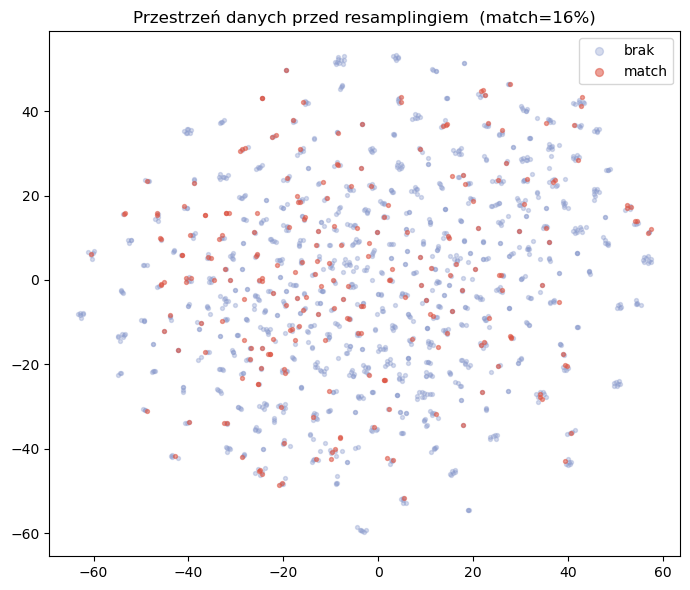

In [101]:
sub = np.random.RandomState(42).choice(X_train.index, size=1500, replace=False)
Xe = preprocess.fit_transform(X_train.loc[sub])
ys = y_train.loc[sub].values

emb = TSNE(n_components=2, init='pca', perplexity=30, random_state=42).fit_transform(Xe)

plt.figure(figsize=(7, 6))
plt.scatter(emb[ys==0,0], emb[ys==0,1], s=8, alpha=.35, color='#8899cc', label='brak')
plt.scatter(emb[ys==1,0], emb[ys==1,1], s=8, alpha=.55, color='#dd5544', label='match')
plt.title(f'Przestrzeń danych przed resamplingiem  (match={ys.mean():.0%})')
plt.legend(markerscale=2); plt.tight_layout(); plt.show()

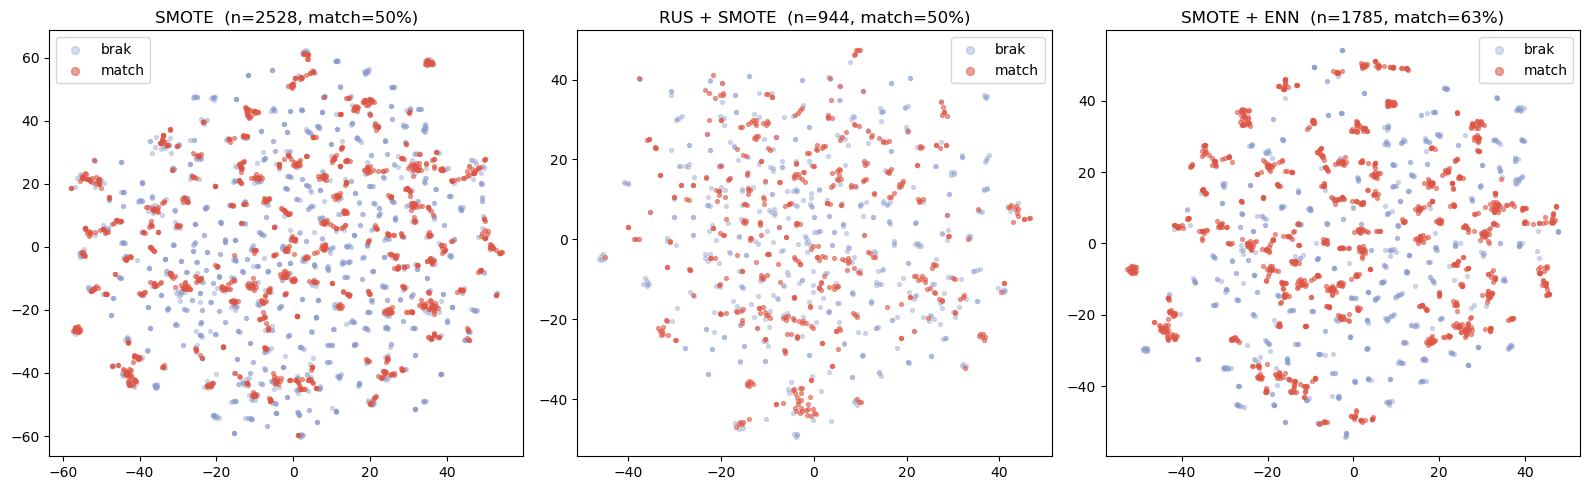

In [ ]:
def rus_smote(X, y):
    X, y = RandomUnderSampler(sampling_strategy=0.5, random_state=42).fit_resample(X, y)
    return SMOTE(random_state=42).fit_resample(X, y)

variants = {
    'SMOTE':       SMOTE(random_state=42).fit_resample(Xe, ys),
    'RUS + SMOTE': rus_smote(Xe, ys),
    'SMOTE + ENN': SMOTEENN(random_state=42).fit_resample(Xe, ys),
}

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
for ax, (title, (Xv, yv)) in zip(axes, variants.items()):
    emb = TSNE(n_components=2, init='pca', perplexity=30,
               random_state=42).fit_transform(Xv)
    ax.scatter(emb[yv==0,0], emb[yv==0,1], s=8, alpha=.35, color='#8899cc', label='brak')
    ax.scatter(emb[yv==1,0], emb[yv==1,1], s=8, alpha=.55, color='#dd5544', label='match')
    ax.set_title(f"{title}  (n={len(yv)}, match={np.mean(yv):.0%})")
    ax.legend(markerscale=2)
plt.tight_layout(); plt.show()

In [103]:
def make(steps):
    return ImbPipe([('pre', preprocess)] + steps +
                   [('clf', LogisticRegression(max_iter=1000))])

configs = {
    '(baseline)': [],
    'SMOTE':      [('sm', SMOTE(random_state=42))],
    'RUS+SMOTE':  [('rus', RandomUnderSampler(sampling_strategy=0.5, random_state=42)),
                   ('sm', SMOTE(random_state=42))],
    'SMOTE+ENN':  [('se', SMOTEENN(random_state=42))],
}

print(f"{'metoda':12s}{'recall':>8s}{'prec':>8s}{'f1':>8s}")
for nm, st in configs.items():
    p = make(st).fit(X_train, y_train).predict(X_test)
    print(f"{nm:12s}{recall_score(y_test,p):>8.3f}"
          f"{precision_score(y_test,p,zero_division=0):>8.3f}"
          f"{f1_score(y_test,p,zero_division=0):>8.3f}")

metoda        recall    prec      f1
(baseline)     0.006   0.125   0.012
SMOTE          0.401   0.247   0.306
RUS+SMOTE      0.408   0.218   0.284
SMOTE+ENN      0.561   0.213   0.308



Każda metoda resamplingu drastycznie podnosi recall klasy mniejszościowej (z ~0.01 do 0.40–0.56), kosztem precyzji - to kompromis: model
przestaje ignorować matche, ale częściej myli się na "brakach".
SMOTE generuje syntetyczne matche przez interpolację, daje najlepszy balans.
RUS + SMOTE osiąga podobny recall na mniejszym zbiorze, ale przez agresywne przycięcie większości traci nieco precyzji.
SMOTE + ENN ma najwyższy recall (0.56) - ENN czyści sporne punkty na granicy klas, przez co model łapie najwięcej matchy, ale jest najmniej precyzyjny.

Przy równym F1 decyduje kontekst - czy ważniejsze jest złapanie matcha (recall), czy uniknięcie fałszywej rekomendacji (precision).

### Zadanie 1.5 - modele ensemble dla danych niezbalansowanych

In [104]:

models = {
    'SMOTE+logreg':   make([('sm', SMOTE(random_state=42))]),    
    'RF class_weight': ImbPipe([('pre', preprocess),
        ('clf', RandomForestClassifier(n_estimators=300, class_weight='balanced',
                                       random_state=42, n_jobs=-1))]),
    'BalancedRF':     ImbPipe([('pre', preprocess),
        ('clf', BalancedRandomForestClassifier(n_estimators=300, sampling_strategy='all',
                replacement=True, bootstrap=True, random_state=42, n_jobs=-1))]),
    'EasyEnsemble':   ImbPipe([('pre', preprocess),
        ('clf', EasyEnsembleClassifier(n_estimators=20, random_state=42, n_jobs=-1))]),
}

print(f"{'model':18s}{'recall':>8s}{'prec':>7s}{'f1':>7s}{'AUC':>7s}{'AP':>7s}")
fitted = {}
for nm, m in models.items():
    m.fit(X_train, y_train); fitted[nm] = m
    p = m.predict(X_test); proba = m.predict_proba(X_test)[:, 1]
    print(f"{nm:18s}{recall_score(y_test,p):>8.3f}{precision_score(y_test,p,zero_division=0):>7.3f}"
          f"{f1_score(y_test,p,zero_division=0):>7.3f}{roc_auc_score(y_test,proba):>7.3f}"
          f"{average_precision_score(y_test,proba):>7.3f}")

model               recall   prec     f1    AUC     AP
SMOTE+logreg         0.401  0.247  0.306  0.549  0.216
RF class_weight      0.000  0.000  0.000  0.618  0.270
BalancedRF           0.223  0.289  0.252  0.609  0.257
EasyEnsemble         0.592  0.234  0.336  0.596  0.258


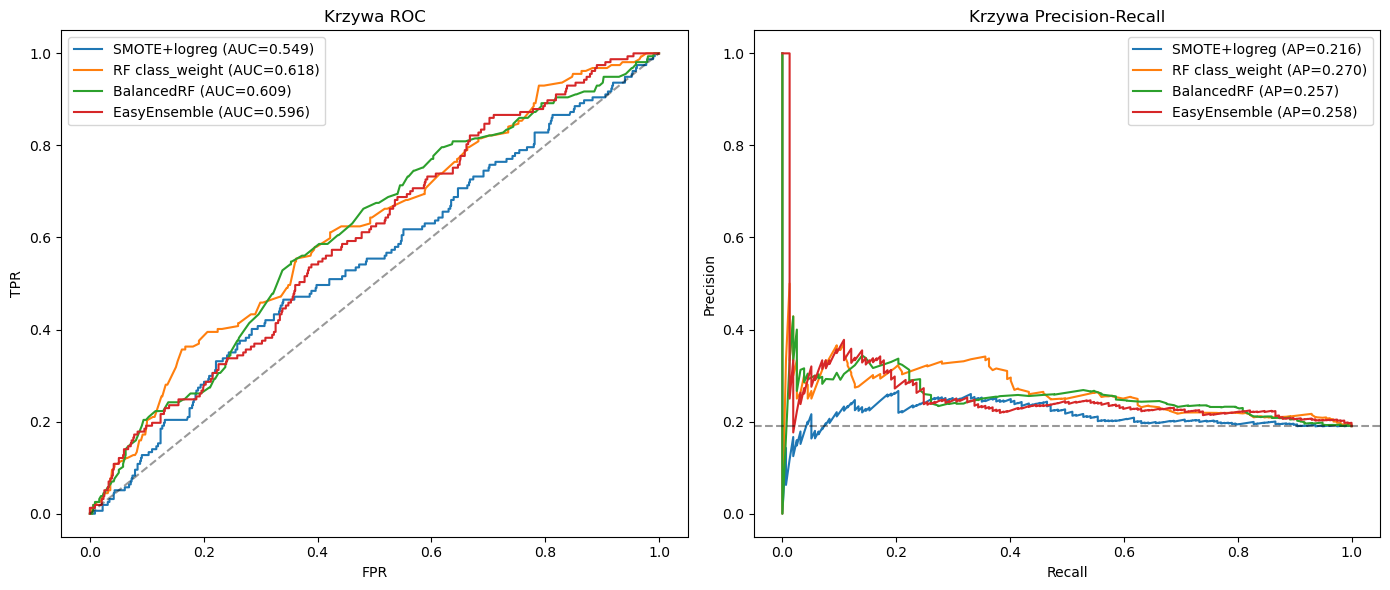

In [105]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
for nm, m in fitted.items():
    proba = m.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, proba)
    ax1.plot(fpr, tpr, label=f"{nm} (AUC={roc_auc_score(y_test,proba):.3f})")
    prec, rec, _ = precision_recall_curve(y_test, proba)
    ax2.plot(rec, prec, label=f"{nm} (AP={average_precision_score(y_test,proba):.3f})")

ax1.plot([0,1],[0,1],'k--',alpha=.4)      
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('Krzywa ROC'); ax1.legend()
ax2.axhline(y_test.mean(), color='k', ls='--', alpha=.4) 
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision'); ax2.set_title('Krzywa Precision-Recall'); ax2.legend()
plt.tight_layout(); plt.show()

RF z class_weight ma recall = 0 przy progu 0.5, ale najwyższe AUC/AP - dobrze
rankuje matche, tylko jego prawdopodobieństwa leżą poniżej 0.5. To kwestia progu,
nie modelu. EasyEnsemble daje najlepszy balans (f1 = 0.34).

Dla rekomendacji właściwsza jest krzywa PR niż ROC - przy niezbalansowaniu ROC
zawyża ocenę. AP ≈ 0.22-0.27 vs base rate 0.19 pokazuje,
że modele biją losowość, ale nieznacznie.

### Zadanie 2.1 - metryki rekomendacyjne 

In [ ]:
def precision_at_k(g, k):
    return g.sort_values('p', ascending=False).head(k)['y'].mean()

def reciprocal_rank(g):
    order = g.sort_values('p', ascending=False)['y'].values
    hits = np.where(order == 1)[0]
    return 1 / (hits[0] + 1) if len(hits) else 0.0

def rec_metrics(proba):
    ev = pd.DataFrame({'uid': uid_test.values, 'y': y_test.values, 'p': proba})
    g = ev.groupby('uid')
    return {
        'P@1': g.apply(lambda x: precision_at_k(x, 1), include_groups=False).mean(),
        'P@3': g.apply(lambda x: precision_at_k(x, 3), include_groups=False).mean(),
        'MRR': g.apply(reciprocal_rank, include_groups=False).mean(),
    }

print(f"{'model':16s}{'P@1':>7s}{'P@3':>7s}{'MRR':>7s}")
for nm, m in fitted.items():
    r = rec_metrics(m.predict_proba(X_test)[:, 1])
    print(f"{nm:16s}{r['P@1']:>7.3f}{r['P@3']:>7.3f}{r['MRR']:>7.3f}")

rng_ref = np.random.default_rng(0)
r_rand = rec_metrics(rng_ref.random(len(y_test)))
print(f"{'losowy':16s}{r_rand['P@1']:>7.3f}{r_rand['P@3']:>7.3f}{r_rand['MRR']:>7.3f}")

model               P@1    P@3    MRR
SMOTE+logreg      0.206  0.204  0.338
RF class_weight   0.224  0.202  0.348
BalancedRF        0.224  0.214  0.353
EasyEnsemble      0.212  0.208  0.351
losowy            0.164  0.190  0.311


Wszystkie modele biją losowy ranking (MRR ~0.35 vs 0.31, P@1 ~0.22 vs 0.16),
ale różnice między nimi mieszczą się w granicach szumu - profil to słaby sygnał.

Kluczowa obserwacja: globalne AUC nie przekłada się na ranking wewnątrz usera.
Precision@K i MRR liczą się per user (5 kandydatów), więc mierzą realne UX -
czy match trafia na górę feedu danej osoby - a nie uśrednioną dokładność po
wszystkich parach. Dla rekomendacji to właściwsza miara niż accuracy/F1.


### Zadanie 2.2 - model romantyczny (maksymalizacja recall)

wybrany próg romantyczny: 0.06


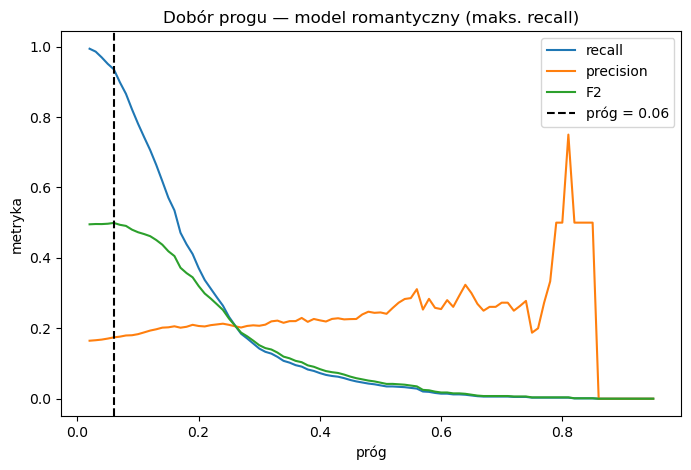

TEST  recall=0.885  precision=0.195  f1=0.320


In [107]:
from sklearn.model_selection import cross_val_predict, StratifiedGroupKFold
from sklearn.metrics import fbeta_score

model = ImbPipe([('pre', preprocess), ('clf', LogisticRegression(max_iter=1000))])

cv = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
oof = cross_val_predict(model, X_train, y_train, cv=cv,
                        groups=uid_train, method='predict_proba')[:, 1]

ths = np.linspace(0.02, 0.95, 94)
f2   = [fbeta_score(y_train, (oof >= t).astype(int), beta=2, zero_division=0) for t in ths]
rec  = [recall_score(y_train,  (oof >= t).astype(int)) for t in ths]
prec = [precision_score(y_train,(oof >= t).astype(int), zero_division=0) for t in ths]
t_rom = ths[int(np.argmax(f2))]
print(f'wybrany próg romantyczny: {t_rom:.2f}')

plt.figure(figsize=(8,5))
plt.plot(ths, rec, label='recall'); plt.plot(ths, prec, label='precision'); plt.plot(ths, f2, label='F2')
plt.axvline(t_rom, ls='--', color='k', label=f'próg = {t_rom:.2f}')
plt.xlabel('próg'); plt.ylabel('metryka'); plt.legend()
plt.title('Dobór progu — model romantyczny (maks. recall)'); plt.show()

model.fit(X_train, y_train)
proba_test = model.predict_proba(X_test)[:, 1]
pred_rom = (proba_test >= t_rom).astype(int)
print(f'TEST  recall={recall_score(y_test,pred_rom):.3f}  '
      f'precision={precision_score(y_test,pred_rom,zero_division=0):.3f}  '
      f'f1={f1_score(y_test,pred_rom,zero_division=0):.3f}')

Cel: maksymalna szansa na znalezienie partnera = maksymalny recall. Wynik na teście: recall = 0.89, precision = 0.20. Model łapie niemal wszystkie
matche, ale ~80% jego rekomendacji to fałszywe trafienia. To logiczny skutek
filozofii "partner ponad wszystko" - nie filtruj nikogo, kosztem zalania
użytkownika nietrafionymi propozycjami.

### Zadanie 2.3 - model biznesowy

wybrany próg biznesowy: 0.81


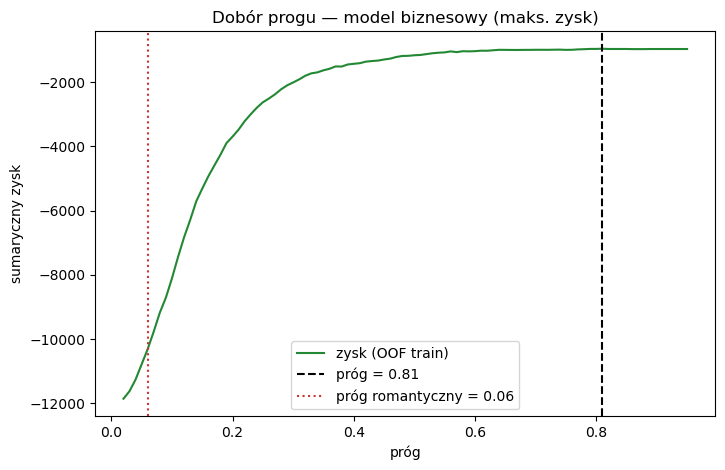

TEST  recall=0.000  precision=0.000  f1=0.000
zysk na teście: -157


In [108]:
V = {'TP': 3, 'TN': 0, 'FP': -3, 'FN': -1}

def profit(y_true, y_pred):
    """sumaryczny zysk wg macierzy kosztów"""
    tp = ((y_pred == 1) & (y_true == 1)).sum()
    tn = ((y_pred == 0) & (y_true == 0)).sum()
    fp = ((y_pred == 1) & (y_true == 0)).sum()
    fn = ((y_pred == 0) & (y_true == 1)).sum()
    return tp*V['TP'] + tn*V['TN'] + fp*V['FP'] + fn*V['FN']

profits = [profit(y_train.values, (oof >= t).astype(int)) for t in ths]
t_biz = ths[int(np.argmax(profits))]
print(f'wybrany próg biznesowy: {t_biz:.2f}')

plt.figure(figsize=(8,5))
plt.plot(ths, profits, color='#228833', label='zysk (OOF train)')
plt.axvline(t_biz, ls='--', color='k', label=f'próg = {t_biz:.2f}')
plt.axvline(t_rom, ls=':', color='#cc3333', label=f'próg romantyczny = {t_rom:.2f}')
plt.xlabel('próg'); plt.ylabel('sumaryczny zysk'); plt.legend()
plt.title('Dobór progu — model biznesowy (maks. zysk)'); plt.show()

pred_biz = (proba_test >= t_biz).astype(int)
print(f'TEST  recall={recall_score(y_test,pred_biz):.3f}  '
      f'precision={precision_score(y_test,pred_biz,zero_division=0):.3f}  '
      f'f1={f1_score(y_test,pred_biz,zero_division=0):.3f}')
print(f'zysk na teście: {profit(y_test.values, pred_biz)}')

Macierz kosztów: TP=+3, TN=0, FP=−3, FN=−1. Strategia: FP najdroższe - pudło to
same negatywy (zmarnowany czas, frustracja, ryzyko złej opinii). FN tańsze, bo
przeoczony match oznacza, że user zostaje w apce. TP skromne, bo znaleziony partner
też odchodzi. Próg dobieramy maksymalizując sumaryczny zysk na prawdopodobieństwach
out-of-fold.

### Zadanie 2.4 - porównanie

In [109]:
rows = []
for nm, pred, t in [('Romantyczny', pred_rom, t_rom), ('Biznesowy', pred_biz, t_biz)]:
    rows.append({
        'model': nm, 'próg': round(t, 2),
        'recall':    round(recall_score(y_test, pred), 3),
        'precision': round(precision_score(y_test, pred, zero_division=0), 3),
        'f1':        round(f1_score(y_test, pred, zero_division=0), 3),
        'zysk':      profit(y_test.values, pred),
    })

for nm, pred in [('polecaj wszystkich', np.ones(len(y_test), int)),
                 ('polecaj nikogo',     np.zeros(len(y_test), int))]:
    rows.append({'model': nm, 'próg': None,
                 'recall':    round(recall_score(y_test, pred), 3),
                 'precision': round(precision_score(y_test, pred, zero_division=0), 3),
                 'f1':        round(f1_score(y_test, pred, zero_division=0), 3),
                 'zysk':      profit(y_test.values, pred)})

porownanie = pd.DataFrame(rows)
print(porownanie.to_string(index=False))

             model  próg  recall  precision   f1  zysk
       Romantyczny  0.06   0.885      0.195 0.32 -1320
         Biznesowy  0.81   0.000      0.000 0.00  -157
polecaj wszystkich   NaN   1.000      0.190 0.32 -1533
    polecaj nikogo   NaN   0.000      0.000 0.00  -157


## Podsumowanie

**Część 1.** Po usunięciu wycieków problem jest trudny: match to 18%, a model bazowy
mimo 81% accuracy łapie ~1% matchy. Resampling i modele ensemble podniosły recall do
0.40-0.56 kosztem precyzji. Krzywe PR (AP ≈ 0.22-0.27 vs base rate 0.19) pokazują, że
sygnał profilowy jest słaby.

**Część 2.** Ten sam klasyfikator realizuje przeciwne strategie tylko przez zmianę progu:
romantyczny (próg ~0.06) maksymalizuje recall, biznesowy minimalizuje stratę wg macierzy
kosztów. Przy drogim FP optimum kosztowe degeneruje się do "nie polecaj nikomu" - co
obnaża napięcie biznes-produkt.

**Wniosek główny:** techniki dla danych niezbalansowanych skutecznie zmieniają zachowanie
modelu zgodnie z celem, ale nie zastąpią informacji, której w danych nie ma. Po wycięciu
wycieków profil niesie zbyt słaby sygnał  wąskim gardłem jest jakość danych, nie metoda.